# Irrigation Need — Notebook 3: LightGBM
**Kaggle Playground S6E4**

Inputs:
- `Data/processed/train_unscaled.parquet`
- `Data/processed/test_unscaled.parquet`
- `Data/processed/sample_weights.parquet`
- `Data/processed/class_weights.pkl`
- `Data/processed/target_map.pkl`

Outputs:
- `submissions/submission_lgbm.csv`
- `models/lgbm_best_params.pkl`
- `models/lgbm_oof_preds.parquet`
- `models/lgbm_test_probs.parquet`

Strategy:
1. Baseline — formula argmax only (no ML)
2. Ablation — formula features only vs all features
3. Manual grid search — 3 param sets × 5-fold CV (lightweight, no Optuna)
4. Final model — retrain with best params, save OOF + test probs for ensemble


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from matplotlib.patches import Patch

pd.set_option('display.float_format', '{:.4f}'.format)
PALETTE = {'Low': '#02C39A', 'Medium': '#F4A261', 'High': '#E63946'}
SEED    = 42
N_FOLDS = 5

os.makedirs('../models', exist_ok=True)
os.makedirs('../submissions', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
train = pd.read_parquet('../Data/processed/train_unscaled.parquet')
test  = pd.read_parquet('../Data/processed/test_unscaled.parquet')

with open('../Data/processed/class_weights.pkl', 'rb') as f:
    cw = pickle.load(f)
class_weight_dict = cw['class_weight_dict']

with open('../Data/processed/target_map.pkl', 'rb') as f:
    tm = pickle.load(f)
target_inv = tm['inv']  # {0: 'Low', 1: 'Medium', 2: 'High'}

sample_weights = pd.read_parquet('../Data/processed/sample_weights.parquet')['sample_weight'].values

y      = train['Irrigation_Need'].values
X      = train.drop(columns=['Irrigation_Need'])
X_test = test.copy()

print(f'Train : {X.shape}')
print(f'Test  : {X_test.shape}')
print(f'Target: {pd.Series(y).value_counts().to_dict()}')

Train : (630000, 37)
Test  : (270000, 37)
Target: {0: 369917, 1: 239074, 2: 21009}


## 2. Baseline — Formula Only (No ML)

Formula baseline — Balanced Accuracy: 0.9610

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.92      0.92      0.92     21009

    accuracy                           0.98    630000
   macro avg       0.96      0.96      0.96    630000
weighted avg       0.98      0.98      0.98    630000



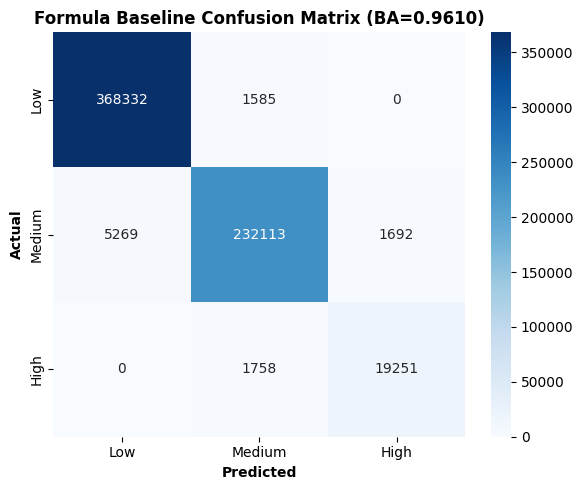

In [3]:
prob_cols    = ['prob_low', 'prob_medium', 'prob_high']
formula_pred = np.argmax(X[prob_cols].values, axis=1)
ba_formula   = balanced_accuracy_score(y, formula_pred)

print(f'Formula baseline — Balanced Accuracy: {ba_formula:.4f}')
print()
print(classification_report(y, formula_pred, target_names=['Low', 'Medium', 'High']))

cm = confusion_matrix(y, formula_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=ax)
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('Actual', fontweight='bold')
ax.set_title(f'Formula Baseline Confusion Matrix (BA={ba_formula:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Sets & Ablation

In [14]:
formula_cols = [
    'soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10',
    'CGS_Flowering', 'CGS_Harvest', 'CGS_Sowing', 'CGS_Vegetative',
    'mulch_no', 'mulch_yes',
    'logit_low', 'logit_medium', 'logit_high',
    'prob_low', 'prob_medium', 'prob_high',
    'rule_score', 'logit_margin'
]

all_features     = X.columns.tolist()
formula_features = [c for c in formula_cols if c in X.columns]

print(f'Feature set A (all):     {len(all_features)} features')
print(f'Feature set B (formula): {len(formula_features)} features')

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

base_params = {
    'objective':     'multiclass',
    'num_class':     3,
    'metric':        'multi_logloss',
    'verbosity':     -1,
    'n_estimators':  500,
    'learning_rate': 0.05,
    'num_leaves':    31,
    'random_state':  SEED,
}

def quick_cv(feature_cols, label):
    scores = []
    X_sub  = X[feature_cols].values
    for tr_idx, val_idx in skf.split(X_sub, y):
        X_tr, X_val = X_sub[tr_idx], X_sub[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = lgb.LGBMClassifier(**base_params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weights[tr_idx],
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False),
                       lgb.log_evaluation(-1)]
        )
        scores.append(balanced_accuracy_score(y_val, model.predict(X_val)))
    mean_ba = np.mean(scores)
    print(f'{label:30s} → CV BA: {mean_ba:.4f}  folds: {[round(s,4) for s in scores]}')
    return mean_ba

print('=== Ablation Study ===')
ba_formula_only = quick_cv(formula_features, 'Formula features only')
ba_all          = quick_cv(all_features,     'All features')
print(f'\nDelta from adding original features: {ba_all - ba_formula_only:+.4f}')

v2_cols = [c for c in X.columns if c not in [
    'soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10',
    'CGS_Flowering', 'CGS_Harvest', 'CGS_Sowing', 'CGS_Vegetative',
    'mulch_no', 'mulch_yes'
]]
ba_v2 = quick_cv(v2_cols, 'Raw + logit/prob only (v2)')

FEATURE_COLS = v2_cols
print(f'Selected: v2 ({len(v2_cols)} features)')

Feature set A (all):     37 features
Feature set B (formula): 18 features
=== Ablation Study ===
Formula features only          → CV BA: 0.9633  folds: [0.9625, 0.9635, 0.9651, 0.9626, 0.963]
All features                   → CV BA: 0.9701  folds: [0.9686, 0.9699, 0.9714, 0.9704, 0.9698]

Delta from adding original features: +0.0067
Raw + logit/prob only (v2)     → CV BA: 0.9700  folds: [0.9686, 0.9707, 0.9708, 0.9701, 0.97]
Selected: v2 (27 features)


## 4. Manual Grid Search

In [15]:
COMMON = {
    'objective':    'multiclass',
    'num_class':    3,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'random_state': SEED,
}

param_grid = {
    'conservative': {
        **COMMON,
        'n_estimators':      500,
        'learning_rate':     0.05,
        'num_leaves':        63,
        'max_depth':         6,
        'min_child_samples': 50,
        'subsample':         0.8,
        'colsample_bytree':  0.8,
        'reg_alpha':         0.1,
        'reg_lambda':        1.0,
    },
    'deeper': {
        **COMMON,
        'n_estimators':      800,
        'learning_rate':     0.03,
        'num_leaves':        127,
        'max_depth':         8,
        'min_child_samples': 30,
        'subsample':         0.7,
        'colsample_bytree':  0.7,
        'reg_alpha':         0.05,
        'reg_lambda':        0.5,
    },
    'fast': {
        **COMMON,
        'n_estimators':      300,
        'learning_rate':     0.1,
        'num_leaves':        31,
        'max_depth':         5,
        'min_child_samples': 100,
        'subsample':         0.9,
        'colsample_bytree':  0.9,
        'reg_alpha':         0.01,
        'reg_lambda':        0.1,
    },
}

X_arr      = X[FEATURE_COLS].values
X_test_arr = X_test[FEATURE_COLS].values
grid_results = {}

print('=== Manual Grid Search (3 param sets × 5 folds = 15 fits) ===')
for name, params in param_grid.items():
    fold_scores = []
    for tr_idx, val_idx in skf.split(X_arr, y):
        X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sample_weights[tr_idx],
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)]
        )
        fold_scores.append(balanced_accuracy_score(y_val, model.predict(X_val)))

    mean_ba = np.mean(fold_scores)
    grid_results[name] = {'mean_ba': mean_ba, 'fold_scores': fold_scores, 'params': params}
    print(f'  {name:15s} → BA: {mean_ba:.4f}  folds: {[round(s,4) for s in fold_scores]}')

best_name   = max(grid_results, key=lambda k: grid_results[k]['mean_ba'])
best_params = grid_results[best_name]['params']
best_ba     = grid_results[best_name]['mean_ba']

print(f'\nBest param set  : {best_name}')
print(f'Best CV BA      : {best_ba:.4f}')
print(f'Formula baseline: {ba_formula:.4f}')
print(f'Improvement     : {best_ba - ba_formula:+.4f}')

=== Manual Grid Search (3 param sets × 5 folds = 15 fits) ===
  conservative    → BA: 0.9699  folds: [0.9689, 0.9698, 0.9712, 0.9699, 0.9697]
  deeper          → BA: 0.9665  folds: [0.9657, 0.9666, 0.9679, 0.9651, 0.967]
  fast            → BA: 0.9705  folds: [0.9697, 0.9707, 0.9711, 0.9705, 0.9707]

Best param set  : fast
Best CV BA      : 0.9705
Formula baseline: 0.9610
Improvement     : +0.0096


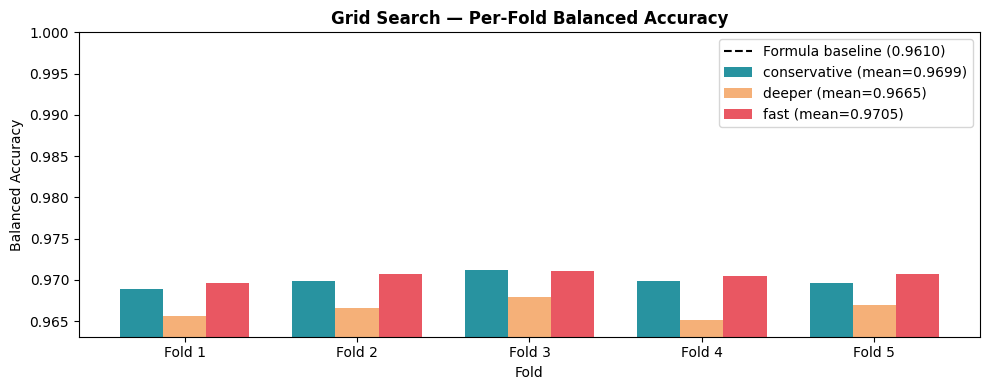

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(N_FOLDS)
width  = 0.25
colors_grid = ['#028090', '#F4A261', '#E63946']

for i, (name, res) in enumerate(grid_results.items()):
    ax.bar(x + i*width, res['fold_scores'], width,
           label=f"{name} (mean={res['mean_ba']:.4f})",
           color=colors_grid[i], alpha=0.85)

ax.axhline(ba_formula, color='black', linestyle='--', linewidth=1.5,
           label=f'Formula baseline ({ba_formula:.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Grid Search — Per-Fold Balanced Accuracy', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.legend()
ax.set_ylim(min(s for r in grid_results.values() for s in r['fold_scores']) - 0.002, 1.0)
plt.tight_layout()
plt.show()

## 5. Final Model — OOF + Test Predictions

In [18]:
oof_preds   = np.zeros(len(X), dtype=int)
oof_probs   = np.zeros((len(X), 3))
test_probs  = np.zeros((len(X_test), 3))
fold_scores = []

print(f'=== Final Model ({best_name}) — {N_FOLDS}-Fold CV ===')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y)):
    X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=sample_weights[tr_idx],
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)]
    )

    val_probs          = model.predict_proba(X_val)
    val_preds          = np.argmax(val_probs, axis=1)
    oof_preds[val_idx] = val_preds
    oof_probs[val_idx] = val_probs
    test_probs        += model.predict_proba(X_test_arr) / N_FOLDS

    fold_ba = balanced_accuracy_score(y_val, val_preds)
    fold_scores.append(fold_ba)
    print(f'  Fold {fold+1}: BA = {fold_ba:.4f}  |  trees = {model.best_iteration_}')

oof_ba = balanced_accuracy_score(y, oof_preds)
print(f'\nOOF Balanced Accuracy : {oof_ba:.4f}')
print(f'Mean fold BA          : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')
print(f'Formula baseline      : {ba_formula:.4f}')
print(f'Improvement           : {oof_ba - ba_formula:+.4f}')

=== Final Model (fast) — 5-Fold CV ===
  Fold 1: BA = 0.9697  |  trees = 300
  Fold 2: BA = 0.9707  |  trees = 300
  Fold 3: BA = 0.9711  |  trees = 300
  Fold 4: BA = 0.9705  |  trees = 300
  Fold 5: BA = 0.9707  |  trees = 300

OOF Balanced Accuracy : 0.9705
Mean fold BA          : 0.9705 ± 0.0005
Formula baseline      : 0.9610
Improvement           : +0.0096


## 6. OOF Diagnostics

=== OOF Classification Report ===
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.90      0.95      0.92     21009

    accuracy                           0.98    630000
   macro avg       0.96      0.97      0.96    630000
weighted avg       0.98      0.98      0.98    630000



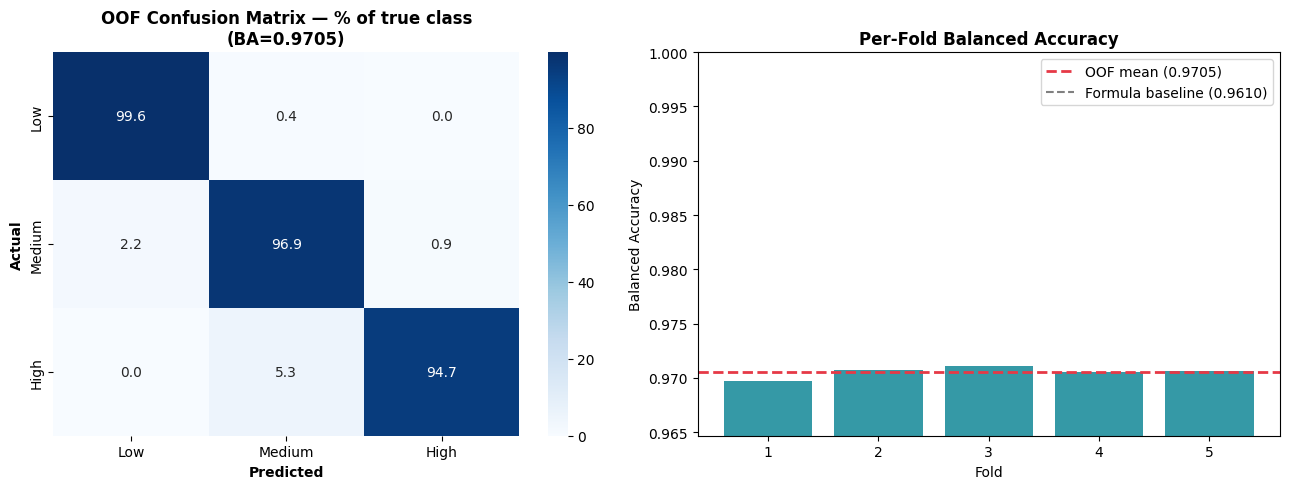

In [19]:
print('=== OOF Classification Report ===')
print(classification_report(y, oof_preds, target_names=['Low', 'Medium', 'High']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm     = confusion_matrix(y, oof_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'], ax=axes[0])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'OOF Confusion Matrix — % of true class\n(BA={oof_ba:.4f})', fontweight='bold')

axes[1].bar(range(1, N_FOLDS+1), fold_scores, color='#028090', alpha=0.8)
axes[1].axhline(oof_ba, color='#E63946', linestyle='--', linewidth=2,
                label=f'OOF mean ({oof_ba:.4f})')
axes[1].axhline(ba_formula, color='grey', linestyle='--', linewidth=1.5,
                label=f'Formula baseline ({ba_formula:.4f})')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Per-Fold Balanced Accuracy', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(min(fold_scores) - 0.005, 1.0)
plt.tight_layout()
plt.show()

## 7. Feature Importance

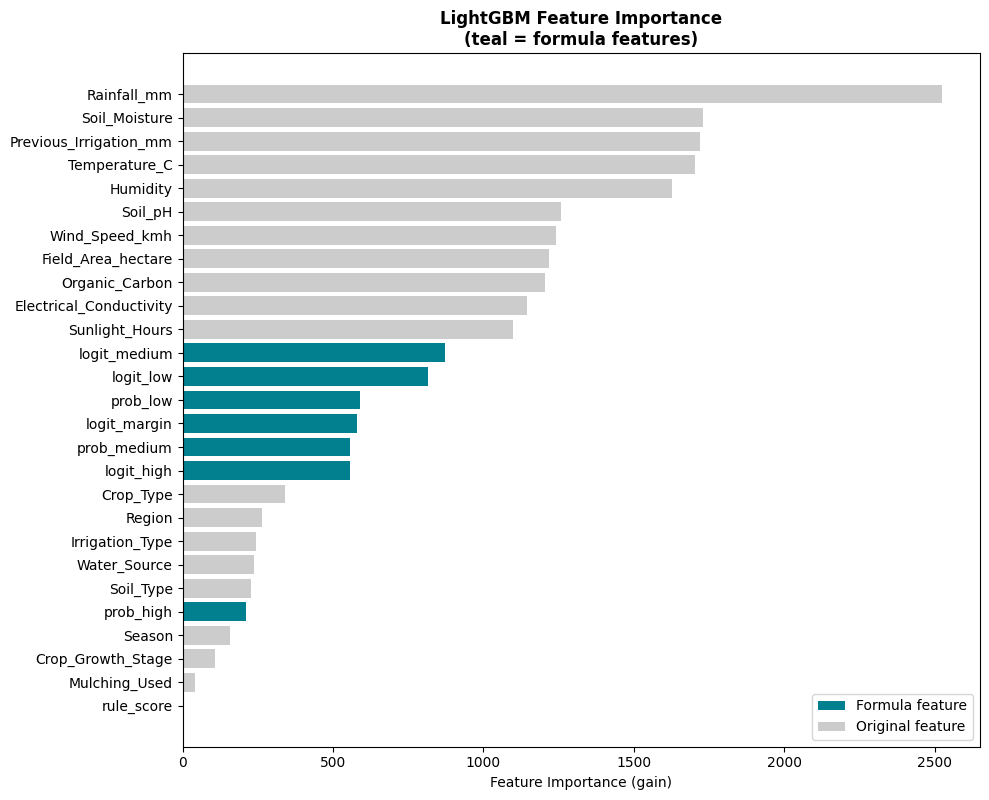

Top 15 features:
Rainfall_mm                2524
Soil_Moisture              1731
Previous_Irrigation_mm     1719
Temperature_C              1703
Humidity                   1626
Soil_pH                    1258
Wind_Speed_kmh             1240
Field_Area_hectare         1217
Organic_Carbon             1203
Electrical_Conductivity    1144
Sunlight_Hours             1099
logit_medium                872
logit_low                   817
prob_low                    588
logit_margin                580


In [20]:
fi = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

formula_set = set(formula_features)
colors_fi   = ['#028090' if f in formula_set else '#cccccc' for f in fi.index]

fig, ax = plt.subplots(figsize=(10, max(6, len(fi)*0.3)))
ax.barh(fi.index, fi.values, color=colors_fi)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('LightGBM Feature Importance\n(teal = formula features)', fontweight='bold')
legend_elements = [Patch(facecolor='#028090', label='Formula feature'),
                   Patch(facecolor='#cccccc', label='Original feature')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 15 features:')
print(fi.sort_values(ascending=False).head(15).to_string())

## 8. Prediction Distribution Check

=== Prediction Distribution Sanity Check ===
  Train true  : Low 58.7%  Medium 37.9%  High 3.3%
  OOF preds   : Low 59.3%  Medium 37.2%  High 3.5%
  Test preds  : Low 59.2%  Medium 37.3%  High 3.5%


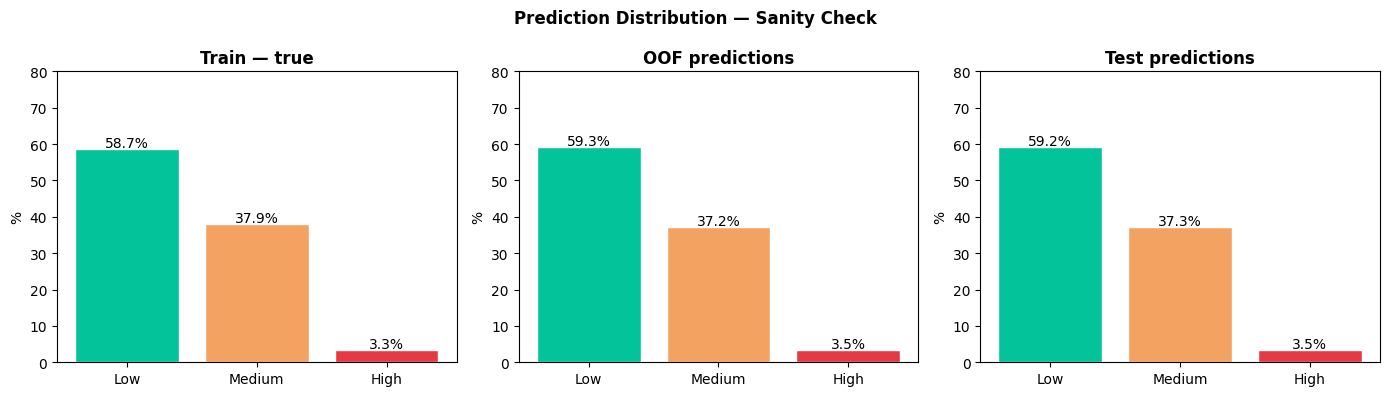

In [21]:
test_preds  = np.argmax(test_probs, axis=1)
test_labels = pd.Series(test_preds).map(target_inv)
oof_labels  = pd.Series(oof_preds).map(target_inv)
true_labels = pd.Series(y).map(target_inv)

order = ['Low', 'Medium', 'High']
print('=== Prediction Distribution Sanity Check ===')
for name, series in [('Train true', true_labels),
                     ('OOF preds',  oof_labels),
                     ('Test preds', test_labels)]:
    vc = series.value_counts(normalize=True).reindex(order).mul(100).round(1)
    print(f'  {name:12s}: Low {vc["Low"]}%  Medium {vc["Medium"]}%  High {vc["High"]}%')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_bar = [PALETTE[c] for c in order]

for ax, (title, series) in zip(axes, [
    ('Train — true',   true_labels),
    ('OOF predictions', oof_labels),
    ('Test predictions', test_labels),
]):
    vc = series.value_counts(normalize=True).reindex(order) * 100
    ax.bar(order, vc.values, color=colors_bar, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('%')
    ax.set_ylim(0, 80)
    for i, v in enumerate(vc.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Prediction Distribution — Sanity Check', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Save Outputs

In [22]:
# Submission
submission = pd.DataFrame({
    'id': X_test.index,
    'Irrigation_Need': test_labels.values
})
submission.to_csv('../submissions/submission_lgbm.csv', index=False)
print('Saved: submissions/submission_lgbm.csv')
print(submission['Irrigation_Need'].value_counts())

# OOF predictions for ensemble
oof_df = pd.DataFrame({
    'y_true':          y,
    'oof_pred':        oof_preds,
    'oof_prob_low':    oof_probs[:, 0],
    'oof_prob_medium': oof_probs[:, 1],
    'oof_prob_high':   oof_probs[:, 2],
}, index=X.index)
oof_df.to_parquet('../models/lgbm_oof_preds.parquet')
print('Saved: models/lgbm_oof_preds.parquet')

# Test probabilities for ensemble
test_probs_df = pd.DataFrame(
    test_probs,
    columns=['lgbm_prob_low', 'lgbm_prob_medium', 'lgbm_prob_high'],
    index=X_test.index
)
test_probs_df.to_parquet('../models/lgbm_test_probs.parquet')
print('Saved: models/lgbm_test_probs.parquet')

# Best params
with open('../models/lgbm_best_params.pkl', 'wb') as f:
    pickle.dump({'name': best_name, 'params': best_params}, f)
print('Saved: models/lgbm_best_params.pkl')

Saved: submissions/submission_lgbm.csv
Irrigation_Need
Low       159913
Medium    100637
High        9450
Name: count, dtype: int64
Saved: models/lgbm_oof_preds.parquet
Saved: models/lgbm_test_probs.parquet
Saved: models/lgbm_best_params.pkl


## 10. Summary

In [12]:
print('=' * 65)
print('LIGHTGBM SUMMARY')
print('=' * 65)
print(f"""
BASELINE
  Formula-only BA                : {ba_formula:.4f}

ABLATION
  Formula features only (CV)     : {ba_formula_only:.4f}
  All features (CV)              : {ba_all:.4f}
  Delta                          : {ba_all - ba_formula_only:+.4f}
  Selected feature set           : {'all' if FEATURE_COLS == all_features else 'formula only'}

GRID SEARCH
""")
for name, res in grid_results.items():
    marker = ' ← best' if name == best_name else ''
    print(f'  {name:15s}: {res["mean_ba"]:.4f}{marker}')

print(f"""
FINAL MODEL ({best_name})
  OOF Balanced Accuracy          : {oof_ba:.4f}
  Fold scores                    : {[round(s,4) for s in fold_scores]}
  Std across folds               : {np.std(fold_scores):.4f}
  Improvement over formula       : {oof_ba - ba_formula:+.4f}

OUTPUTS
  submissions/submission_lgbm.csv
  models/lgbm_oof_preds.parquet
  models/lgbm_test_probs.parquet
  models/lgbm_best_params.pkl
""")
print('=' * 65)
print('→ Proceed to 04_Model_XGBoost.ipynb')
print('=' * 65)

LIGHTGBM SUMMARY

BASELINE
  Formula-only BA                : 0.9610

ABLATION
  Formula features only (CV)     : 0.9633
  All features (CV)              : 0.9701
  Delta                          : +0.0067
  Selected feature set           : all

GRID SEARCH

  conservative   : 0.9699
  deeper         : 0.9666
  fast           : 0.9706 ← best

FINAL MODEL (fast)
  OOF Balanced Accuracy          : 0.9706
  Fold scores                    : [0.9699, 0.971, 0.9711, 0.9707, 0.9706]
  Std across folds               : 0.0004
  Improvement over formula       : +0.0097

OUTPUTS
  submissions/submission_lgbm.csv
  models/lgbm_oof_preds.parquet
  models/lgbm_test_probs.parquet
  models/lgbm_best_params.pkl

→ Proceed to 04_Model_XGBoost.ipynb
